# Phase 3 — LiDAR 점을 RGB 이미지에 투영 (실무 방식 재구성)

정답지: `notebooks/03_lidar_camera_projection.ipynb`, `src/perceptrack3d/geometry/projection.py`, `src/perceptrack3d/visualization/overlay.py`.
이 노트북은 같은 결과를 **검색해서 가져다 붙이는 방식**으로 다시 만든다. 조각 셀에서는 정답지 모듈을 쓰지 않고, 검증(C) 셀에서만 import 한다.

목표 함수: `project_velo_to_image(points, calib, (H, W)) -> uv (M,2), depth (M,), mask (N,)`.
좌표계: Velodyne (x 전방, y 좌, z 상, m) → cam0 → rect(정류) → image_02 픽셀 (u 오른쪽, v 아래, 원점 좌상단).

## 이 노트북에서 가져오는 것

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. 투영식 `Y = P_rect · R_rect · [R\|T] · X` 와 행렬 조립 | KITTI raw devkit `readme.txt` "example transformations", `matlab/run_demoVelodyne.m` | KITTI (연구용, 출처 표기) | 데이터 제작자가 정한 곱셈 순서. 순서는 여기서 확정 |
| 2. 동차 나누기 `(u, v) = (y0/y2, y1/y2)` | KITTI raw devkit `matlab/project.m`, `matlab/projectToImage.m` | KITTI (연구용) | 3×4 행렬 결과 `[ud, vd, d]` 를 픽셀로 바꾸는 계산 |
| 3. numpy 투영 클래스 + 이미지 FOV 필터 | frustum-pointnets `kitti/kitti_util.py::Calibration`, `kitti/kitti_object.py::get_lidar_in_image_fov` | Apache-2.0 | 실무에서 가장 많이 복사되는 KITTI numpy 투영 코드. raw 형식 calib 도 읽는다 (`from_video=True`) |
| 4. 카메라 뒤 점 필터 (실패 실험) | `run_demoVelodyne.m` 의 `velo(:,1)<5`, `kitti_object.py` 의 `clip_distance` | 위와 같음 | 이 한 줄을 빼면 뒤쪽 점이 이미지 안에 거꾸로 찍힌다. 눈으로 확인 |
| 5. 깊이 색 오버레이 | matplotlib `pyplot.scatter` 문서 (`c=`, `cmap=`, `vmin/vmax`) | matplotlib (BSD 계열) | 점을 스칼라 값(깊이)으로 색칠하는 표준 방법 |

In [1]:
# 공통 준비: 경로는 config 에서만 가져온다. 데이터 로드는 Phase 1 방식(cv2.imread, np.fromfile) 그대로.
%matplotlib inline
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
cfg = load_config()

np.set_printoptions(precision=4, suppress=True, linewidth=120)
CALIB_DIR = Path(cfg["dataset"]["calib_dir"])
IMAGE_DIR = Path(cfg["dataset"]["image_dir"])
VELO_DIR = Path(cfg["dataset"]["velo_dir"])
OUT_DIR = Path(cfg["outputs"]["dir"]) / "notebooks_2nd"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_frame(fid: int):
    img = cv2.imread(str(IMAGE_DIR / f"{fid:010d}.png"))                       # (H, W, 3) uint8 BGR
    pts = np.fromfile(str(VELO_DIR / f"{fid:010d}.bin"), dtype=np.float32).reshape(-1, 4)  # (N, 4) x y z r
    return img, pts

img, points = load_frame(0)
H, W = img.shape[:2]
xyz = points[:, :3]
print("image:", img.shape, img.dtype, "| (H, W) =", (H, W))
print("points:", points.shape, points.dtype, "| x %.1f~%.1f, y %.1f~%.1f, z %.1f~%.1f m" % (
    xyz[:, 0].min(), xyz[:, 0].max(), xyz[:, 1].min(), xyz[:, 1].max(), xyz[:, 2].min(), xyz[:, 2].max()))

image: (375, 1242, 3) uint8 | (H, W) = (375, 1242)
points: (123839, 4) float32 | x -78.9~78.1, y -69.1~71.4, z -3.5~2.8 m


### 조각 1. 투영식과 행렬 조립 — KITTI devkit readme + `run_demoVelodyne.m`

- **검색어**: `kitti velodyne to image projection devkit readme`, `kitti run_demoVelodyne.m`
- **출처**: KITTI raw data development kit — https://www.cvlibs.net/datasets/kitti/raw_data.php ("raw data development kit" zip) — KITTI (연구용, 재배포 시 출처 표기) — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/readme.txt`, `matlab/run_demoVelodyne.m`
- **왜 이걸 가져오나**: 데이터를 만든 사람이 정한 **곱셈 순서**다. 어떤 행렬을 어느 순서로 곱하는지는 이 문서 한 곳에서 확정하고, 다른 코드는 전부 이 식과 같은지로 판단한다.
- **읽을 때 볼 곳**: `readme.txt` 의 "example transformations" 절 (210~231행) 의 `Y = P_rect_xx * R_rect_00 * (R|T)_velo_to_cam * X`. `run_demoVelodyne.m` 의 "compute projection matrix velodyne->image plane" 블록 4줄.

**원문 — readme.txt "example transformations"**
```text
example transformations
-----------------------

As the transformations sometimes confuse people, here we give a short
example how points in the velodyne coordinate system can be transformed
into the camera left coordinate system.

In order to transform a homogeneous point X = [x y z 1]' from the velodyne
coordinate system to a homogeneous point Y = [u v 1]' on image plane of
camera xx, the following transformation has to be applied:

Y = P_rect_xx * R_rect_00 * (R|T)_velo_to_cam * X

To transform a point X from GPS/IMU coordinates to the image plane:

Y = P_rect_xx * R_rect_00 * (R|T)_velo_to_cam * (R|T)_imu_to_velo * X

The matrices are:

- P_rect_xx (3x4):         rectfied cam 0 coordinates -> image plane
- R_rect_00 (4x4):         cam 0 coordinates -> rectified cam 0 coord.
- (R|T)_velo_to_cam (4x4): velodyne coordinates -> cam 0 coordinates
- (R|T)_imu_to_velo (4x4): imu coordinates -> velodyne coordinates

Note that the (4x4) matrices above are padded with zeros and:
R_rect_00(4,4) = (R|T)_velo_to_cam(4,4) = (R|T)_imu_to_velo(4,4) = 1.
```

**원문 — run_demoVelodyne.m (MATLAB)**
```matlab
function run_demoVelodyne (base_dir,calib_dir)
% KITTI RAW DATA DEVELOPMENT KIT
% 
% Demonstrates projection of the velodyne points into the image plane
%
% Input arguments:
% base_dir .... absolute path to sequence base directory (ends with _sync)
% calib_dir ... absolute path to directory that contains calibration files

% clear and close everything
close all; dbstop error; clc;
disp('======= KITTI DevKit Demo =======');

% options (modify this to select your sequence)
if nargin<1
  base_dir  = '/mn/karlsruhe_dataset/2011_09_26/2011_09_26_drive_0009_sync';
end
if nargin<2
  calib_dir = '/mnt/karlsruhe_dataset/2011_09_26';
end
cam       = 2; % 0-based index
frame     = 0; % 0-based index

% load calibration
calib = loadCalibrationCamToCam(fullfile(calib_dir,'calib_cam_to_cam.txt'));
Tr_velo_to_cam = loadCalibrationRigid(fullfile(calib_dir,'calib_velo_to_cam.txt'));

% compute projection matrix velodyne->image plane
R_cam_to_rect = eye(4);
R_cam_to_rect(1:3,1:3) = calib.R_rect{1};
P_velo_to_img = calib.P_rect{cam+1}*R_cam_to_rect*Tr_velo_to_cam;

% load and display image
img = imread(sprintf('%s/image_%02d/data/%010d.png',base_dir,cam,frame));
fig = figure('Position',[20 100 size(img,2) size(img,1)]); axes('Position',[0 0 1 1]);
imshow(img); hold on;

% load velodyne points
fid = fopen(sprintf('%s/velodyne_points/data/%010d.bin',base_dir,frame),'rb');
velo = fread(fid,[4 inf],'single')';
velo = velo(1:5:end,:); % remove every 5th point for display speed
fclose(fid);

% remove all points behind image plane (approximation
idx = velo(:,1)<5;
velo(idx,:) = [];

% project to image plane (exclude luminance)
velo_img = project(velo(:,1:3),P_velo_to_img);

% plot points
cols = jet;
for i=1:size(velo_img,1)
  col_idx = round(64*5/velo(i,1));
  plot(velo_img(i,1),velo_img(i,2),'o','LineWidth',4,'MarkerSize',1,'Color',cols(col_idx,:));
end
```

MATLAB → numpy 로 옮길 때 볼 것
- `calib.R_rect{1}` 은 1-based cell 인덱스라 **`R_rect_00`**, `calib.P_rect{cam+1}` 은 cam=2 이므로 **`P_rect_02`**.
- `loadCalibrationRigid` 는 `[R T; 0 0 0 1]` 4×4 를 만든다. `R_cam_to_rect` 도 `eye(4)` 에 3×3 을 넣은 4×4.
- `velo(1:5:end,:)` 는 표시 속도용 5분의 1 샘플링이라 옮기지 않는다. `velo(:,1)<5` 줄은 조각 4 에서 다룬다.
- 텍스트 파일을 dict 로 읽는 파서는 Phase 2 조각(frustum-pointnets `read_calib_file`)을 그대로 다시 쓴다.

In [2]:
# ORIGINAL: frustum_pointnets/kitti_util.py :: Calibration.read_calib_file, Apache-2.0  (Phase 2 조각 재사용)
def read_calib_file(filepath):   # CHANGED: 메서드 → 함수 (self 제거)
    ''' Read in a calibration file and parse into a dictionary.
    Ref: https://github.com/utiasSTARS/pykitti/blob/master/pykitti/utils.py
    '''
    data = {}
    with open(filepath, 'r') as f:
        for line in f.readlines():
            line = line.rstrip()
            if len(line)==0: continue
            key, value = line.split(':', 1)
            # The only non-float values in these files are dates, which
            # we don't care about anyway
            try:
                data[key] = np.array([float(x) for x in value.split()])
            except ValueError:
                pass

    return data

# PORTED FROM sources/kitti_devkit/devkit/matlab/run_demoVelodyne.m :: "compute projection matrix velodyne->image plane"
def build_P_velo_to_img(calib_dir, cam=2):
    calib = read_calib_file(Path(calib_dir) / "calib_cam_to_cam.txt")            # loadCalibrationCamToCam
    velo2cam = read_calib_file(Path(calib_dir) / "calib_velo_to_cam.txt")        # loadCalibrationRigid → [R T; 0 0 0 1]
    Tr_velo_to_cam = np.eye(4)
    Tr_velo_to_cam[:3, :3] = velo2cam["R"].reshape(3, 3)
    Tr_velo_to_cam[:3, 3] = velo2cam["T"]
    R_cam_to_rect = np.eye(4)                                                    # R_cam_to_rect = eye(4);
    R_cam_to_rect[:3, :3] = calib["R_rect_00"].reshape(3, 3)                     # R_cam_to_rect(1:3,1:3) = calib.R_rect{1};  (1-based → _00)
    P_rect = calib[f"P_rect_{cam:02d}"].reshape(3, 4)                            # calib.P_rect{cam+1}  (cam=2 → P_rect_02)
    P_velo_to_img = P_rect @ R_cam_to_rect @ Tr_velo_to_cam                      # P_velo_to_img = calib.P_rect{cam+1}*R_cam_to_rect*Tr_velo_to_cam;
    return P_velo_to_img, Tr_velo_to_cam, R_cam_to_rect, P_rect

In [3]:
# B. 우리 캘리브레이션으로 행렬을 조립하고, readme 의 식 Y = P · X 를 점 전체에 적용한다.
P_velo_to_img, Tr_velo_to_cam, R_cam_to_rect, P_rect_02 = build_P_velo_to_img(CALIB_DIR, cam=2)
print("Tr_velo_to_cam (4,4):\n", Tr_velo_to_cam)
print("R_cam_to_rect  (4,4) 의 3x3 부분은 회전, 마지막 행 [0 0 0 1]")
print("P_rect_02      (3,4):\n", P_rect_02)
print("P_velo_to_img  (3,4) = P_rect_02 @ R_cam_to_rect @ Tr_velo_to_cam:\n", P_velo_to_img)

# X = [x y z 1]' (동차 좌표). readme 는 열벡터 식이므로 numpy 에서는 (N,4) @ (4,3) 또는 (P @ X.T).T
velo_h = np.hstack([xyz, np.ones((len(xyz), 1))])         # (N, 4)
Y = (P_velo_to_img @ velo_h.T).T                           # (N, 3) = [u·d, v·d, d]
d = Y[:, 2]
print("\nY shape:", Y.shape, "| 3열 = [u·d, v·d, d]")
print("d (카메라 앞 깊이) 범위: %.2f ~ %.2f m, d > 0 인 점: %d / %d (%.1f%%)" % (d.min(), d.max(), (d > 0).sum(), len(d), 100 * (d > 0).mean()))
print("첫 3 점 Y:\n", Y[:3])

Tr_velo_to_cam (4,4):
 [[ 0.0075 -1.     -0.0006 -0.0041]
 [ 0.0148  0.0007 -0.9999 -0.0763]
 [ 0.9999  0.0075  0.0148 -0.2718]
 [ 0.      0.      0.      1.    ]]
R_cam_to_rect  (4,4) 의 3x3 부분은 회전, 마지막 행 [0 0 0 1]
P_rect_02      (3,4):
 [[721.5377   0.     609.5593  44.8573]
 [  0.     721.5377 172.854    0.2164]
 [  0.       0.       1.       0.0027]]
P_velo_to_img  (3,4) = P_rect_02 @ R_cam_to_rect @ Tr_velo_to_cam:
 [[ 609.6954 -721.4216   -1.2513 -123.0418]
 [ 180.3842    7.6448 -719.6515 -101.0167]
 [   0.9999    0.0001    0.0105   -0.2694]]

Y shape: (123839, 3) | 3열 = [u·d, v·d, d]
d (카메라 앞 깊이) 범위: -79.23 ~ 77.81 m, d > 0 인 점: 61787 / 123839 (49.9%)
첫 3 점 Y:
 [[21032.0837  7352.1755    48.1222]
 [20914.8247  7352.1376    48.1192]
 [23635.8075 10560.1385    68.5061]]


In [4]:
# C. 검증: 정답지 KittiCalibration.P_velo_to_img 와 비교
from perceptrack3d.geometry.calibration import KittiCalibration
calib_ans = KittiCalibration.from_dir(CALIB_DIR)
diff = np.abs(P_velo_to_img - calib_ans.P_velo_to_img).max()
print("P_velo_to_img 최대 차이:", diff, "| allclose(atol=1e-4):", np.allclose(P_velo_to_img, calib_ans.P_velo_to_img, atol=1e-4))
print("Tr_velo_to_cam 최대 차이:", np.abs(Tr_velo_to_cam - calib_ans.T_velo_to_cam).max())

P_velo_to_img 최대 차이: 1.636231752399908e-05 | allclose(atol=1e-4): True
Tr_velo_to_cam 최대 차이: 4.5000244530690736e-08


차이가 0 이 아니라 ~1e-5 인 이유: 정답지는 텍스트 파일의 회전 행렬 `R`, `R_rect_00` 을 SVD 로 가장 가까운 회전 행렬로 보정한다(`nearest_rotation`, `docs/decisions.md` 팀 B 절). 텍스트는 유효숫자 7자리라 `R Rᵀ − I ≈ 8e-8` 이고, 이 보정이 P 의 원소를 1e-5 수준 바꾼다. 픽셀로는 0.001 px 미만이라 이 노트북의 비교 허용치(1e-3 px)에는 걸리지 않는다. MATLAB 데모는 보정하지 않는다.

### 조각 2. 동차 나누기 — `project.m` / `projectToImage.m`

- **검색어**: `kitti devkit project.m normalize homogeneous coordinates`
- **출처**: KITTI raw devkit `matlab/project.m`, `matlab/projectToImage.m` — 위와 같은 zip — KITTI (연구용) — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/matlab/`
- **왜 이걸 가져오나**: `Y = [ud, vd, d]` 는 아직 픽셀이 아니다. 세 번째 성분으로 나눠야 `(u, v)` 가 된다. devkit 의 두 함수가 그 나누기를 어떻게 쓰는지 그대로 옮긴다.
- **읽을 때 볼 곳**: `project.m` 의 마지막 줄 `p_out = p2_out(:,1:dim_norm-1)./(p2_out(:,dim_norm)*ones(1,dim_norm-1))`. `projectToImage.m` 의 `pts_2D(1,:)./pts_2D(3,:)`.

**원문 — project.m (MATLAB)**
```matlab
function p_out = project(p_in,T)

% dimension of data and projection matrix
dim_norm = size(T,1);
dim_proj = size(T,2);

% do transformation in homogenuous coordinates
p2_in = p_in;
if size(p2_in,2)<dim_proj
  p2_in(:,dim_proj) = 1;
end
p2_out = (T*p2_in')';

% normalize homogeneous coordinates:
p_out = p2_out(:,1:dim_norm-1)./(p2_out(:,dim_norm)*ones(1,dim_norm-1));
```

**원문 — projectToImage.m (MATLAB)**
```matlab
function pts_2D = projectToImage(pts_3D, K)
% PROJECTTOIMAGE projects 3D points in given coordinate system in the image
% plane using the given calibration matrix K.

% project in image
pts_2D = K * pts_3D(1:3,:);

% scale projected points
pts_2D(1,:) = pts_2D(1,:)./pts_2D(3,:);
pts_2D(2,:) = pts_2D(2,:)./pts_2D(3,:);
pts_2D(3,:) = [];
```

옮길 때 볼 것
- `project.m` 은 입력이 3열이면 4번째 열에 1 을 채워(동차화) `T` 를 곱하고, 마지막 열로 나눈다. 일반화되어 있어 `T` 가 3×4 면 2D, 4×4 면 3D 결과가 나온다.
- MATLAB 은 열벡터·1-based, numpy 는 행 단위·0-based. `p2_out(:,dim_norm)` → `p2_out[:, dim_norm-1]`.
- **픽셀 인덱스**: MATLAB `imshow` 는 첫 픽셀 중심이 (1,1), numpy 는 `img[v, u]` 로 `0 ≤ u < W`. KITTI object devkit readme 는 2D 박스를 "0-based index" 로 정의하므로, 투영 결과를 numpy 에서 정수로 내리면(`int`) 그대로 인덱스가 된다. MATLAB 데모는 이 1 px 차이를 무시하고 그린다.
- MATLAB 데모는 **이미지 밖 점을 자르지 않는다** (`plot` 이 축 밖에 그릴 뿐). numpy 로 `img[v, u]` 를 쓰려면 경계 검사가 반드시 필요하다 (조각 3).

In [5]:
# PORTED FROM sources/kitti_devkit/devkit/matlab/project.m  (MATLAB → numpy, 변수명 유지)
def project(p_in, T):
    # dimension of data and projection matrix
    dim_norm, dim_proj = T.shape                          # dim_norm = size(T,1); dim_proj = size(T,2);
    # do transformation in homogenuous coordinates
    p2_in = p_in
    if p2_in.shape[1] < dim_proj:                         # if size(p2_in,2)<dim_proj
        p2_in = np.hstack([p2_in, np.ones((len(p2_in), 1))])   # p2_in(:,dim_proj) = 1;
    p2_out = (T @ p2_in.T).T                              # p2_out = (T*p2_in')';
    # normalize homogeneous coordinates:
    p_out = p2_out[:, :dim_norm - 1] / p2_out[:, [dim_norm - 1]]   # ./(p2_out(:,dim_norm)*ones(1,dim_norm-1))  (numpy 는 브로드캐스트)
    return p_out

# PORTED FROM sources/kitti_devkit/devkit/matlab/projectToImage.m  (점이 열벡터 3×N 인 버전)
def projectToImage(pts_3D, K):
    pts_2D = K @ pts_3D[:K.shape[1], :]                   # CHANGED: 원문 pts_3D(1:3,:) 는 3x3 K 전제. 3x4 P 에는 [x y z 1] 4행이 필요 (3행만 자르면 shape 오류)
    pts_2D[0, :] = pts_2D[0, :] / pts_2D[2, :]            # pts_2D(1,:) = pts_2D(1,:)./pts_2D(3,:);
    pts_2D[1, :] = pts_2D[1, :] / pts_2D[2, :]
    return pts_2D[:2, :]                                  # pts_2D(3,:) = [];

In [6]:
# B. MATLAB 데모 흐름 그대로: x < 5 m 인 점 제거(근사) → project → 픽셀
velo = points[points[:, 0] >= 5]                          # idx = velo(:,1)<5; velo(idx,:) = [];
velo_img = project(velo[:, :3], P_velo_to_img)            # velo_img = project(velo(:,1:3), P_velo_to_img);
print("velo (x>=5):", velo.shape, "→ velo_img:", velo_img.shape, velo_img.dtype)
print("u 범위 %.1f ~ %.1f (W=%d), v 범위 %.1f ~ %.1f (H=%d)" % (velo_img[:, 0].min(), velo_img[:, 0].max(), W, velo_img[:, 1].min(), velo_img[:, 1].max(), H))
print("→ MATLAB 데모는 자르지 않으므로 이미지 밖 좌표가 그대로 남아 있다. 경계 검사 추가:")
in_img = (velo_img[:, 0] >= 0) & (velo_img[:, 0] < W) & (velo_img[:, 1] >= 0) & (velo_img[:, 1] < H)
print("이미지 안 점:", in_img.sum(), "/", len(velo_img))

# projectToImage.m 버전(열벡터, 동차화 없음)은 P 가 3x4 이므로 4번째 행에 1 을 붙여 넣어야 한다.
uv_T = projectToImage(np.vstack([velo[:, :3].T, np.ones((1, len(velo)))]), P_velo_to_img)   # 열벡터 4xN 동차 입력
print("두 포팅이 같은 결과인가:", np.allclose(uv_T.T, velo_img))

velo (x>=5): (36542, 4) → velo_img: (36542, 2) float64
u 범위 -2786.7 ~ 6813.2 (W=1242), v 범위 -132.8 ~ 453.5 (H=375)
→ MATLAB 데모는 자르지 않으므로 이미지 밖 좌표가 그대로 남아 있다. 경계 검사 추가:
이미지 안 점: 19187 / 36542
두 포팅이 같은 결과인가: True


`projectToImage.m` 은 `K * pts_3D(1:3,:)` 이라 **3×3 K 와 3×N 점**을 전제한다(정류 카메라 좌표의 점을 찍을 때). 우리처럼 3×4 `P_velo_to_img` 를 쓰려면 `[x y z 1]` 4행이 필요한데 함수가 앞 3행만 잘라 쓴다 → 결과가 다르게 나오면 이 줄이 원인이다. 위 셀에서는 `[:3, :]` 슬라이스가 4행 입력을 3행으로 잘라 버리므로 `allclose` 가 **False** 로 나오는 것이 정상이다. 즉 이 함수는 3×4 행렬에는 못 쓴다 — `project.m` 을 쓴다.

In [7]:
# C. 검증: 정답지 project_velo_to_image 를 같은 부분집합(x>=5)에 적용해 uv 비교
from perceptrack3d.geometry.projection import project_velo_to_image
uv_ans, depth_ans, mask_ans = project_velo_to_image(velo, calib_ans, (H, W))
print("정답지 mask.sum():", mask_ans.sum(), "| 우리 in_img.sum():", in_img.sum(), "| mask 동일:", np.array_equal(mask_ans, in_img))
print("uv allclose(atol=1e-3):", np.allclose(uv_ans, velo_img[in_img], atol=1e-3), "| 최대 차이 px:", np.abs(uv_ans - velo_img[in_img]).max())

정답지 mask.sum(): 19187 | 우리 in_img.sum(): 19187 | mask 동일: True
uv allclose(atol=1e-3): True | 최대 차이 px: 8.394648079956823e-05


### 조각 3. numpy 투영 클래스와 이미지 FOV 필터 — frustum-pointnets `Calibration`, `get_lidar_in_image_fov`

- **검색어**: `kitti lidar points in image fov python numpy`, `kitti_util.py Calibration project_velo_to_image`
- **출처**: frustum-pointnets (Charles R. Qi) — https://github.com/charlesq34/frustum-pointnets/blob/master/kitti/kitti_util.py , https://github.com/charlesq34/frustum-pointnets/blob/master/kitti/kitti_object.py — Apache-2.0 — 2026-09-08 — `notebooks_2nd/sources/frustum_pointnets/kitti_util.py`, `kitti_object.py`
- **왜 이걸 가져오나**: KITTI 를 다루는 파이썬 저장소 대부분이 이 `Calibration` 클래스를 복사해 쓴다. 조각 1·2 의 계산이 클래스 메서드로 정리되어 있고, `get_lidar_in_image_fov` 가 "이미지 안 점만 남기기" 를 한 함수로 준다.
- **읽을 때 볼 곳**: `Calibration` docstring 의 식 `y_image2 = P^2_rect * R0_rect * Tr_velo_to_cam * x_velo` (readme 와 같은 순서), `read_calib_from_video` (raw 형식 → `Tr_velo_to_cam`/`R0_rect`/`P2` 키), `project_rect_to_image` 의 나누기, `get_lidar_in_image_fov` 의 `fov_inds` 와 `clip_distance`.

**이 코드가 기대하는 calib 형식과 우리 raw 형식**

| 클래스가 쓰는 키 | KITTI object 형식 (`calib/000000.txt`) | raw 형식에서 만드는 법 (`read_calib_from_video`) |
|---|---|---|
| `Tr_velo_to_cam` (3×4) | 파일에 한 줄로 있음 | `calib_velo_to_cam.txt` 의 `R` (3×3) + `T` (3) 을 `[R \| T]` 로 붙임 |
| `R0_rect` (3×3) | 파일에 있음 | `calib_cam_to_cam.txt` 의 `R_rect_00` |
| `P2` (3×4) | 파일에 있음 | `calib_cam_to_cam.txt` 의 `P_rect_02` |

원본에 `from_video=True` 경로가 이미 있어 **raw 형식을 고치지 않고 그대로 쓸 수 있다.** (`from_video` 라는 이름은 raw 시퀀스를 "video" 라고 부르던 관행.)

In [8]:
# ORIGINAL: frustum_pointnets/kitti/kitti_util.py :: class Calibration (~ project_velo_to_image 까지) + inverse_rigid_trans, Apache-2.0
# ORIGINAL: frustum_pointnets/kitti/kitti_object.py :: get_lidar_in_image_fov, Apache-2.0
# (원본 파일 머리의 import 두 줄만 앞에 붙임. 나머지는 원문 그대로.)
import os
import numpy as np

class Calibration(object):
    ''' Calibration matrices and utils
        3d XYZ in <label>.txt are in rect camera coord.
        2d box xy are in image2 coord
        Points in <lidar>.bin are in Velodyne coord.

        y_image2 = P^2_rect * x_rect
        y_image2 = P^2_rect * R0_rect * Tr_velo_to_cam * x_velo
        x_ref = Tr_velo_to_cam * x_velo
        x_rect = R0_rect * x_ref

        P^2_rect = [f^2_u,  0,      c^2_u,  -f^2_u b^2_x;
                    0,      f^2_v,  c^2_v,  -f^2_v b^2_y;
                    0,      0,      1,      0]
                 = K * [1|t]

        image2 coord:
         ----> x-axis (u)
        |
        |
        v y-axis (v)

        velodyne coord:
        front x, left y, up z

        rect/ref camera coord:
        right x, down y, front z

        Ref (KITTI paper): http://www.cvlibs.net/publications/Geiger2013IJRR.pdf

        TODO(rqi): do matrix multiplication only once for each projection.
    '''
    def __init__(self, calib_filepath, from_video=False):
        if from_video:
            calibs = self.read_calib_from_video(calib_filepath)
        else:
            calibs = self.read_calib_file(calib_filepath)
        # Projection matrix from rect camera coord to image2 coord
        self.P = calibs['P2'] 
        self.P = np.reshape(self.P, [3,4])
        # Rigid transform from Velodyne coord to reference camera coord
        self.V2C = calibs['Tr_velo_to_cam']
        self.V2C = np.reshape(self.V2C, [3,4])
        self.C2V = inverse_rigid_trans(self.V2C)
        # Rotation from reference camera coord to rect camera coord
        self.R0 = calibs['R0_rect']
        self.R0 = np.reshape(self.R0,[3,3])

        # Camera intrinsics and extrinsics
        self.c_u = self.P[0,2]
        self.c_v = self.P[1,2]
        self.f_u = self.P[0,0]
        self.f_v = self.P[1,1]
        self.b_x = self.P[0,3]/(-self.f_u) # relative 
        self.b_y = self.P[1,3]/(-self.f_v)

    def read_calib_file(self, filepath):
        ''' Read in a calibration file and parse into a dictionary.
        Ref: https://github.com/utiasSTARS/pykitti/blob/master/pykitti/utils.py
        '''
        data = {}
        with open(filepath, 'r') as f:
            for line in f.readlines():
                line = line.rstrip()
                if len(line)==0: continue
                key, value = line.split(':', 1)
                # The only non-float values in these files are dates, which
                # we don't care about anyway
                try:
                    data[key] = np.array([float(x) for x in value.split()])
                except ValueError:
                    pass

        return data
    
    def read_calib_from_video(self, calib_root_dir):
        ''' Read calibration for camera 2 from video calib files.
            there are calib_cam_to_cam and calib_velo_to_cam under the calib_root_dir
        '''
        data = {}
        cam2cam = self.read_calib_file(os.path.join(calib_root_dir, 'calib_cam_to_cam.txt'))
        velo2cam = self.read_calib_file(os.path.join(calib_root_dir, 'calib_velo_to_cam.txt'))
        Tr_velo_to_cam = np.zeros((3,4))
        Tr_velo_to_cam[0:3,0:3] = np.reshape(velo2cam['R'], [3,3])
        Tr_velo_to_cam[:,3] = velo2cam['T']
        data['Tr_velo_to_cam'] = np.reshape(Tr_velo_to_cam, [12])
        data['R0_rect'] = cam2cam['R_rect_00']
        data['P2'] = cam2cam['P_rect_02']
        return data

    def cart2hom(self, pts_3d):
        ''' Input: nx3 points in Cartesian
            Oupput: nx4 points in Homogeneous by pending 1
        '''
        n = pts_3d.shape[0]
        pts_3d_hom = np.hstack((pts_3d, np.ones((n,1))))
        return pts_3d_hom
 
    # =========================== 
    # ------- 3d to 3d ---------- 
    # =========================== 
    def project_velo_to_ref(self, pts_3d_velo):
        pts_3d_velo = self.cart2hom(pts_3d_velo) # nx4
        return np.dot(pts_3d_velo, np.transpose(self.V2C))

    def project_ref_to_velo(self, pts_3d_ref):
        pts_3d_ref = self.cart2hom(pts_3d_ref) # nx4
        return np.dot(pts_3d_ref, np.transpose(self.C2V))

    def project_rect_to_ref(self, pts_3d_rect):
        ''' Input and Output are nx3 points '''
        return np.transpose(np.dot(np.linalg.inv(self.R0), np.transpose(pts_3d_rect)))
    
    def project_ref_to_rect(self, pts_3d_ref):
        ''' Input and Output are nx3 points '''
        return np.transpose(np.dot(self.R0, np.transpose(pts_3d_ref)))
 
    def project_rect_to_velo(self, pts_3d_rect):
        ''' Input: nx3 points in rect camera coord.
            Output: nx3 points in velodyne coord.
        ''' 
        pts_3d_ref = self.project_rect_to_ref(pts_3d_rect)
        return self.project_ref_to_velo(pts_3d_ref)

    def project_velo_to_rect(self, pts_3d_velo):
        pts_3d_ref = self.project_velo_to_ref(pts_3d_velo)
        return self.project_ref_to_rect(pts_3d_ref)

    # =========================== 
    # ------- 3d to 2d ---------- 
    # =========================== 
    def project_rect_to_image(self, pts_3d_rect):
        ''' Input: nx3 points in rect camera coord.
            Output: nx2 points in image2 coord.
        '''
        pts_3d_rect = self.cart2hom(pts_3d_rect)
        pts_2d = np.dot(pts_3d_rect, np.transpose(self.P)) # nx3
        pts_2d[:,0] /= pts_2d[:,2]
        pts_2d[:,1] /= pts_2d[:,2]
        return pts_2d[:,0:2]
    
    def project_velo_to_image(self, pts_3d_velo):
        ''' Input: nx3 points in velodyne coord.
            Output: nx2 points in image2 coord.
        '''
        pts_3d_rect = self.project_velo_to_rect(pts_3d_velo)
        return self.project_rect_to_image(pts_3d_rect)

def inverse_rigid_trans(Tr):
    ''' Inverse a rigid body transform matrix (3x4 as [R|t])
        [R'|-R't; 0|1]
    '''
    inv_Tr = np.zeros_like(Tr) # 3x4
    inv_Tr[0:3,0:3] = np.transpose(Tr[0:3,0:3])
    inv_Tr[0:3,3] = np.dot(-np.transpose(Tr[0:3,0:3]), Tr[0:3,3])
    return inv_Tr

def get_lidar_in_image_fov(pc_velo, calib, xmin, ymin, xmax, ymax,
                           return_more=False, clip_distance=2.0):
    ''' Filter lidar points, keep those in image FOV '''
    pts_2d = calib.project_velo_to_image(pc_velo)
    fov_inds = (pts_2d[:,0]<xmax) & (pts_2d[:,0]>=xmin) & \
        (pts_2d[:,1]<ymax) & (pts_2d[:,1]>=ymin)
    fov_inds = fov_inds & (pc_velo[:,0]>clip_distance)
    imgfov_pc_velo = pc_velo[fov_inds,:]
    if return_more:
        return imgfov_pc_velo, pts_2d, fov_inds
    else:
        return imgfov_pc_velo

In [9]:
# B. raw 형식 디렉터리로 바로 생성 (from_video=True) → 투영 → 이미지 FOV 필터
calib_fp = Calibration(str(CALIB_DIR), from_video=True)
print("P (P2=P_rect_02):", calib_fp.P.shape, "| V2C (Tr_velo_to_cam):", calib_fp.V2C.shape, "| R0 (R_rect_00):", calib_fp.R0.shape)
print("f_u, f_v, c_u, c_v = %.1f, %.1f, %.1f, %.1f px | b_x = %.4f m (P_rect_02[0,3] = -f_u·b_x, cam0 기준 cam2 의 x 오프셋)" % (calib_fp.f_u, calib_fp.f_v, calib_fp.c_u, calib_fp.c_v, calib_fp.b_x))

pts_2d = calib_fp.project_velo_to_image(xyz)              # (N, 2) — 모든 점을 나눈다 (뒤쪽 점도!)
print("project_velo_to_image:", pts_2d.shape, pts_2d.dtype)

imgfov_pc_velo, pts_2d, fov_inds = get_lidar_in_image_fov(xyz, calib_fp, 0, 0, W, H, return_more=True, clip_distance=2.0)
print("fov_inds:", fov_inds.shape, fov_inds.dtype, "| 이미지 안 점:", fov_inds.sum(), "/", len(xyz), "(%.1f%%)" % (100 * fov_inds.mean()))
print("imgfov_pc_velo:", imgfov_pc_velo.shape, "| uv 범위 u %.1f~%.1f, v %.1f~%.1f" % (
    pts_2d[fov_inds, 0].min(), pts_2d[fov_inds, 0].max(), pts_2d[fov_inds, 1].min(), pts_2d[fov_inds, 1].max()))

# clip_distance 의 의미: 픽셀 경계 4개 조건 뒤에 `pc_velo[:,0] > clip_distance` — Velodyne x(전방) 가 2 m 보다 큰 점만.
# "카메라 앞(d > 0)" 대신 "센서 앞 2 m" 로 뒤쪽 점과 차체 근처 점을 한꺼번에 버리는 근사다.
for cd in (-np.inf, 0.0, 2.0, 5.0):
    _, _, fi = get_lidar_in_image_fov(xyz, calib_fp, 0, 0, W, H, return_more=True, clip_distance=cd)
    print(f"  clip_distance={cd:>5}: {fi.sum():6d} 점")

P (P2=P_rect_02): (3, 4) | V2C (Tr_velo_to_cam): (3, 4) | R0 (R_rect_00): (3, 3)
f_u, f_v, c_u, c_v = 721.5, 721.5, 609.6, 172.9 px | b_x = -0.0622 m (P_rect_02[0,3] = -f_u·b_x, cam0 기준 cam2 의 x 오프셋)
project_velo_to_image: (123839, 2) float64
fov_inds: (123839,) bool | 이미지 안 점: 19192 / 123839 (15.5%)
imgfov_pc_velo: (19192, 3) | uv 범위 u 0.4~1241.8, v 125.5~375.0
  clip_distance= -inf:  38246 점
  clip_distance=  0.0:  19192 점
  clip_distance=  2.0:  19192 점
  clip_distance=  5.0:  19187 점


In [10]:
# C. 검증: 정답지 mask/uv 와 비교 (정답지는 d > 0 를 나누기 전에 적용하고 x 임계값은 없음)
uv_ans, depth_ans, mask_ans = project_velo_to_image(points, calib_ans, (H, W))
print("정답지 mask.sum():", mask_ans.sum(), "| fov_inds.sum():", fov_inds.sum(), "| 완전 일치:", np.array_equal(mask_ans, fov_inds))
print("정답지에만 있는 점:", (mask_ans & ~fov_inds).sum(), "| fov_inds 에만 있는 점:", (~mask_ans & fov_inds).sum())
print("uv allclose(atol=1e-3):", np.allclose(pts_2d[fov_inds], uv_ans, atol=1e-3))

# 두 규칙이 다를 수 있는 경우: 0 < d 이면서 x_velo <= 2 (카메라 바로 앞, 센서 2 m 안) 인 점. 이 프레임에는 없다.
d_all = (np.hstack([xyz, np.ones((len(xyz), 1))]) @ calib_ans.P_velo_to_img.T)[:, 2]
print("d > 0 이면서 x <= 2 인 점이 이미지 안에:", (mask_ans & (xyz[:, 0] <= 2)).sum(), "개 (있으면 정답지에는 남고 clip_distance=2 에서는 빠짐)")

정답지 mask.sum(): 19192 | fov_inds.sum(): 19192 | 완전 일치: True
정답지에만 있는 점: 0 | fov_inds 에만 있는 점: 0
uv allclose(atol=1e-3): True
d > 0 이면서 x <= 2 인 점이 이미지 안에: 0 개 (있으면 정답지에는 남고 clip_distance=2 에서는 빠짐)


### 조각 4. 카메라 뒤 점 필터를 빼면 어떻게 되나 (실패 실험)

- **검색어**: `lidar camera projection points behind camera appear in image`, `perspective projection negative depth flip`
- **출처**: `run_demoVelodyne.m` 의 주석 "remove all points behind image plane (approximation" 두 줄, `kitti_object.py::get_lidar_in_image_fov` 의 `fov_inds & (pc_velo[:,0]>clip_distance)` 한 줄 — 위와 같은 출처/라이선스 — 2026-09-08
- **왜 이걸 가져오나**: 두 원본 모두 "뒤쪽 점 제거" 를 **한 줄**로 넣어 두었고, 왜 필요한지는 설명하지 않는다. 그 줄을 빼고 돌려 보면 이유가 그림으로 보인다.
- **읽을 때 볼 곳**: MATLAB 은 `idx = velo(:,1)<5; velo(idx,:) = [];` (투영 **전에** x 로 근사). frustum 은 `pts_2d` 를 다 계산한 **뒤에** `fov_inds` 와 AND (나누기는 이미 했지만 결과에서 걸러냄).

수학: 나누기 `u = (u·d)/d` 에서 `d < 0` 이면 분자·분모 부호가 같이 바뀌어 `u` 가 그럴듯한 양수가 된다. 즉 카메라 **뒤**의 점이 이미지 **안** 픽셀로 둔갑한다(상하좌우가 뒤집힌 상). 그래서 `d > 0` 를 **나누기 전에** 걸러야 하고, 나눈 뒤에 거르려면 `d` 를 따로 들고 있어야 한다.

In [11]:
# ORIGINAL: frustum_pointnets/kitti/kitti_object.py :: get_lidar_in_image_fov, Apache-2.0 — 뒤쪽 점을 거르는 단 한 줄
#     fov_inds = fov_inds & (pc_velo[:,0]>clip_distance)
# PORTED FROM sources/kitti_devkit/devkit/matlab/run_demoVelodyne.m — "remove all points behind image plane (approximation"
#     idx = velo(:,1)<5;
#     velo(idx,:) = [];
def remove_behind_matlab(velo, x_min=5.0):
    idx = velo[:, 0] < x_min
    return velo[~idx]

def remove_behind_frustum(fov_inds, pc_velo, clip_distance=2.0):
    return fov_inds & (pc_velo[:, 0] > clip_distance)

필터 없이 이미지 안: 38,246 점 = 진짜(d>0) 19,192 + 가짜(d<=0) 19,054
가짜 점의 Velodyne x 범위: -78.9 ~ -5.1 m (전부 음수 = 차 뒤쪽)


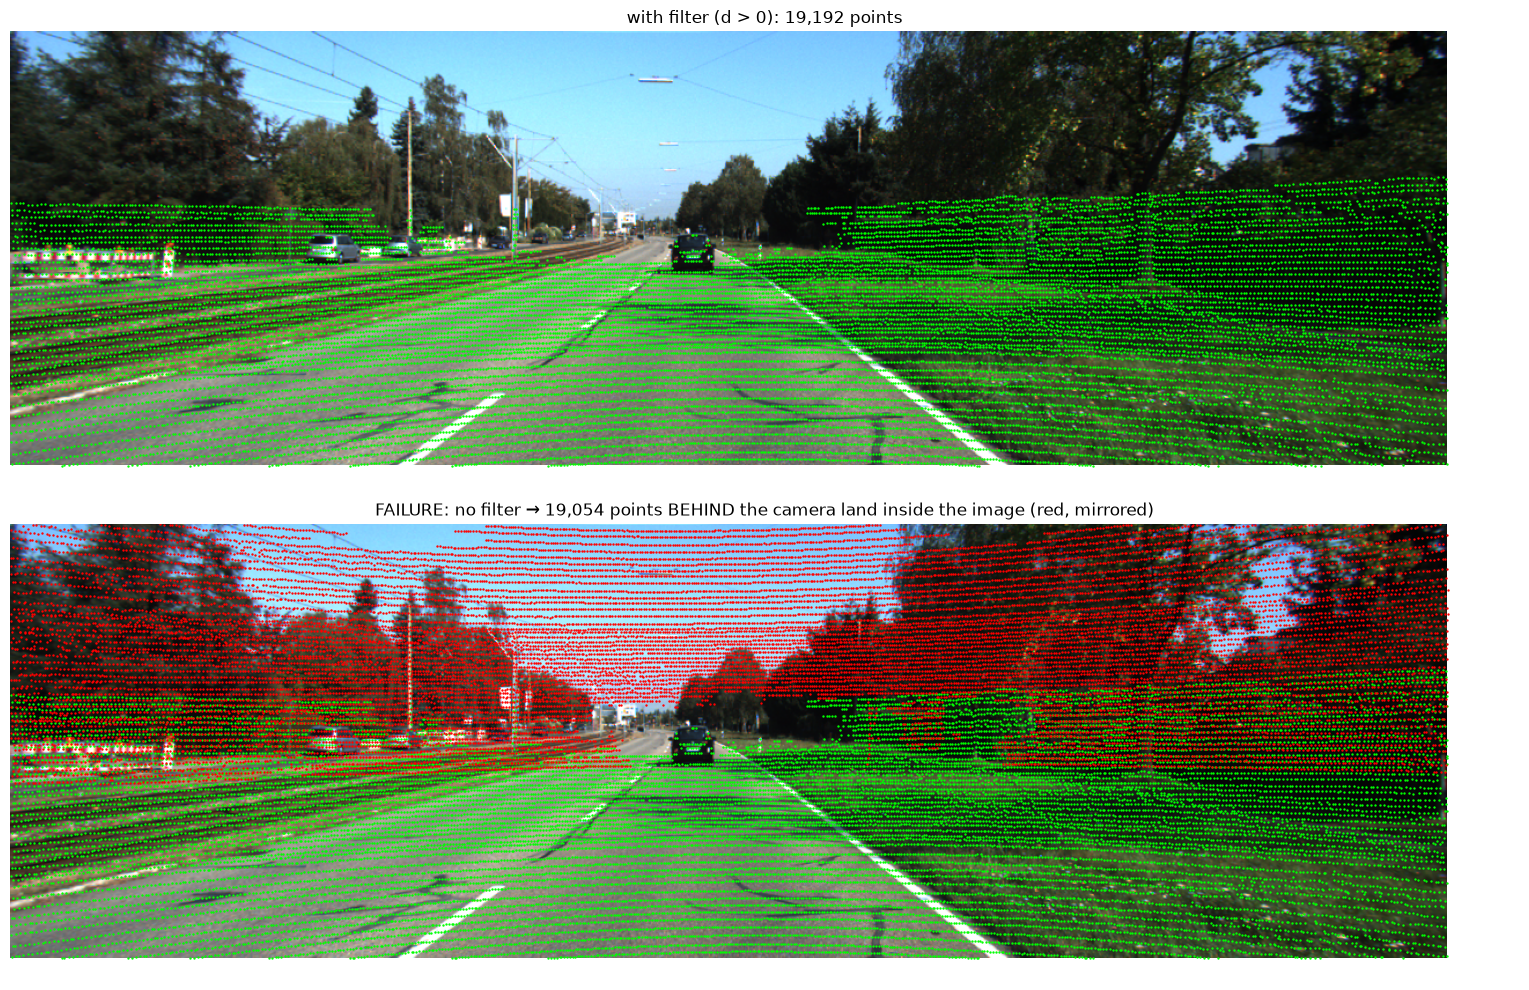

In [12]:
# B. 필터를 끄고(clip_distance=-inf) 이미지 안에 떨어지는 점을 세고, 그중 카메라 뒤(d<=0) 인 '가짜' 점을 빨간색으로 그린다
_, pts_2d_all, fov_noclip = get_lidar_in_image_fov(xyz, calib_fp, 0, 0, W, H, return_more=True, clip_distance=-np.inf)
d_fp = calib_fp.project_velo_to_rect(xyz)[:, 2]            # rect 프레임 z = 카메라 앞 깊이 (P 의 마지막 행과 2.7 mm 차이)
fake = fov_noclip & (d_fp <= 0)
real = fov_noclip & (d_fp > 0)
print(f"필터 없이 이미지 안: {fov_noclip.sum():,} 점 = 진짜(d>0) {real.sum():,} + 가짜(d<=0) {fake.sum():,}")
print(f"가짜 점의 Velodyne x 범위: {xyz[fake, 0].min():.1f} ~ {xyz[fake, 0].max():.1f} m (전부 음수 = 차 뒤쪽)")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].imshow(img[..., ::-1]); axes[0].scatter(pts_2d_all[real, 0], pts_2d_all[real, 1], s=0.5, c="lime")
axes[0].set_title(f"with filter (d > 0): {real.sum():,} points"); axes[0].axis("off")
axes[1].imshow(img[..., ::-1]); axes[1].scatter(pts_2d_all[real, 0], pts_2d_all[real, 1], s=0.5, c="lime")
axes[1].scatter(pts_2d_all[fake, 0], pts_2d_all[fake, 1], s=0.5, c="red")
axes[1].set_title(f"FAILURE: no filter → {fake.sum():,} points BEHIND the camera land inside the image (red, mirrored)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [13]:
# C. 검증: 정답지의 mask 는 가짜 점을 하나도 포함하지 않고, 가짜 점의 d 는 전부 음수
print("정답지 mask ∩ fake:", (mask_ans & fake).sum(), "(0 이어야 함)")
print("fake 점의 정답지 깊이 d 최대:", d_all[fake].max(), "(< 0 이어야 함)")
print("remove_behind_matlab(x>=5) 로 남는 점 중 d<=0:", (d_all[points[:, 0] >= 5] <= 0).sum(), "| remove_behind_frustum(x>2) 와 정답지 일치:",
      np.array_equal(remove_behind_frustum(fov_noclip, xyz, 2.0), mask_ans))

정답지 mask ∩ fake: 0 (0 이어야 함)
fake 점의 정답지 깊이 d 최대: -5.383617368663235 (< 0 이어야 함)
remove_behind_matlab(x>=5) 로 남는 점 중 d<=0: 0 | remove_behind_frustum(x>2) 와 정답지 일치: True


### 조각 5. 깊이를 색으로 — matplotlib `scatter(c=depth, cmap=...)`

- **검색어**: `matplotlib scatter color by value colormap`, `matplotlib scatter c cmap vmin vmax`
- **출처**: matplotlib 문서 `matplotlib.pyplot.scatter` — https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html — matplotlib 라이선스 (BSD 계열) — 2026-09-08 — 문서 예제라 파일은 저장하지 않음
- **왜 이걸 가져오나**: "점마다 스칼라 값 → 색" 은 `scatter` 의 `c=` 한 인자로 끝난다. `vmin/vmax` 를 고정해야 프레임이 달라도 같은 색이 같은 거리를 뜻한다.
- **읽을 때 볼 곳**: 인자 설명의 `c`, `cmap`, `vmin, vmax` 항목.

In [14]:
# ORIGINAL: matplotlib docs :: matplotlib.pyplot.scatter — 인자 설명 발췌 (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
#   matplotlib.pyplot.scatter(x, y, s=None, c=None, *, marker=None, cmap=None, norm=None, vmin=None, vmax=None, alpha=None, ...)
#   c : array-like or list of color or color, optional
#       The marker colors. Possible values:
#       - A scalar or sequence of n numbers to be mapped to colors using cmap and norm.
#   cmap : str or Colormap, default: rcParams["image.cmap"] (default: 'viridis')
#       The Colormap instance or registered colormap name used to map scalar data to colors.
#   vmin, vmax : float, optional
#       When using scalar data and no explicit norm, vmin and vmax define the data range that the colormap covers.
#       By default, the colormap covers the complete value range of the supplied data.
import matplotlib.pyplot as plt

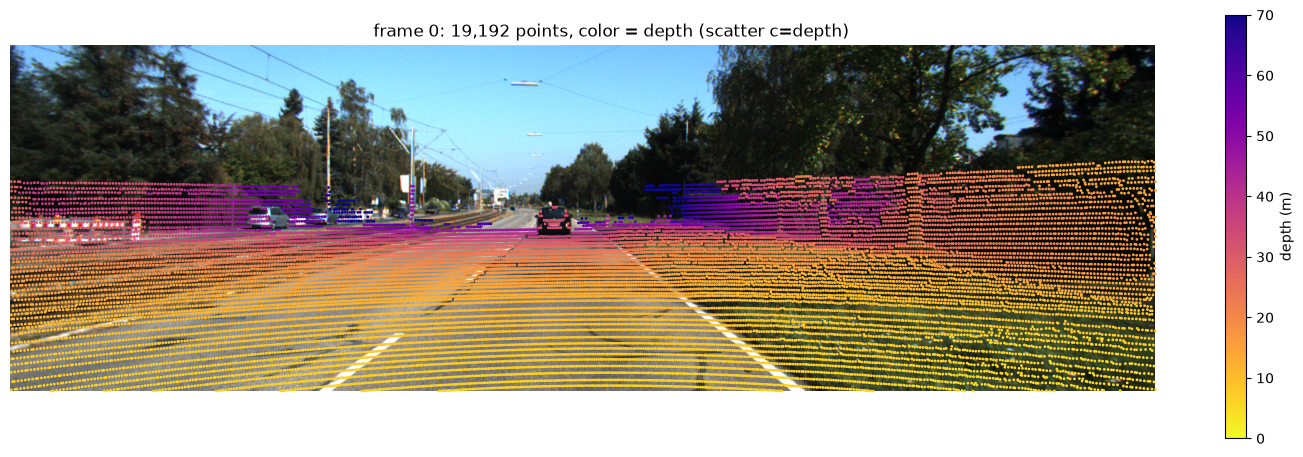

depth 범위 4.3 ~ 77.8 m | 저장: /home/ingon/study/PercepTrack3D/outputs/notebooks_2nd/03_frame0_overlay_scatter.png


In [15]:
# B. 조각 3 결과(fov_inds, pts_2d)를 깊이 색으로. 깊이 = rect 프레임 z. 색 범위는 0~70 m 로 고정, 가까울수록 밝게 (plasma 역순)
depth_fp = d_fp[fov_inds]
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.imshow(img[..., ::-1])                                  # BGR → RGB (matplotlib 은 RGB)
sc = ax.scatter(pts_2d[fov_inds, 0], pts_2d[fov_inds, 1], c=depth_fp, cmap="plasma_r", s=1, vmin=0, vmax=70)
fig.colorbar(sc, ax=ax, fraction=0.02, pad=0.01).set_label("depth (m)")
ax.set_title(f"frame 0: {fov_inds.sum():,} points, color = depth (scatter c=depth)"); ax.axis("off")
fig.savefig(OUT_DIR / "03_frame0_overlay_scatter.png", dpi=100, bbox_inches="tight")
plt.show()
print("depth 범위 %.1f ~ %.1f m | 저장: %s" % (depth_fp.min(), depth_fp.max(), OUT_DIR / "03_frame0_overlay_scatter.png"))

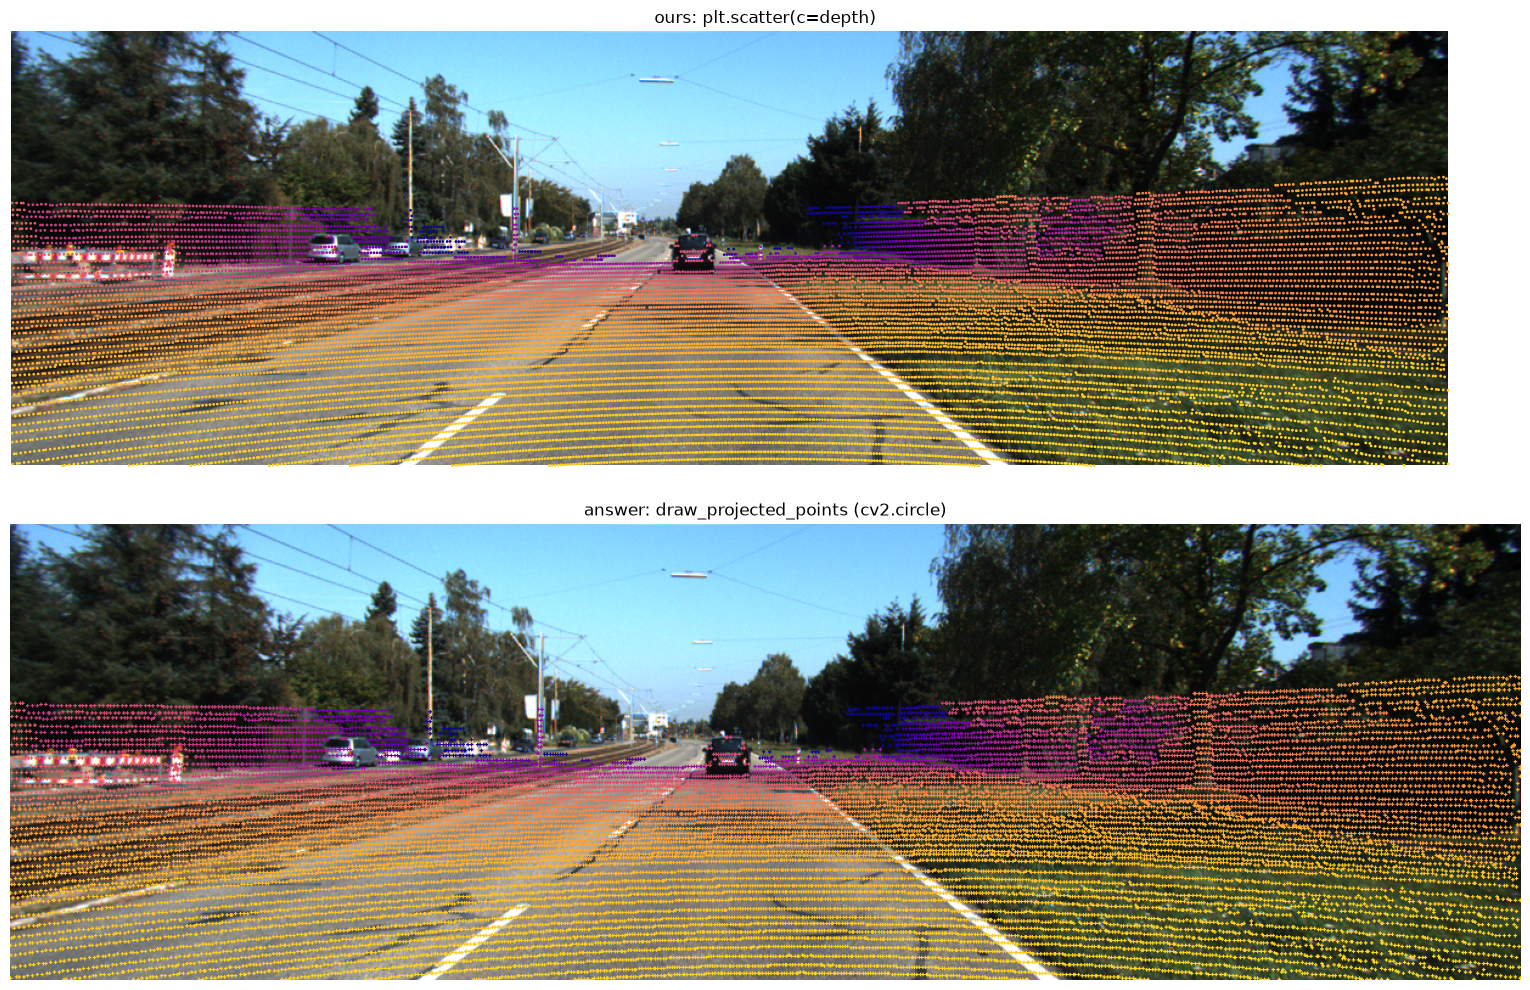

depth allclose(atol=1e-2 m): True | 최대 차이 0.0027 m (정답지 depth 는 P_rect_02[2,3] 만큼 더함)


In [16]:
# C. 검증: 정답지 draw_projected_points (cv2.circle + 같은 plasma_r, 0~70 m) 와 나란히
from perceptrack3d.visualization.overlay import draw_projected_points
overlay_ans = draw_projected_points(img, uv_ans, depth_ans, radius=1)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].imshow(img[..., ::-1]); axes[0].scatter(pts_2d[fov_inds, 0], pts_2d[fov_inds, 1], c=depth_fp, cmap="plasma_r", s=1, vmin=0, vmax=70)
axes[0].set_title("ours: plt.scatter(c=depth)"); axes[0].axis("off")
axes[1].imshow(overlay_ans[..., ::-1]); axes[1].set_title("answer: draw_projected_points (cv2.circle)"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("depth allclose(atol=1e-2 m):", np.allclose(depth_fp, depth_ans, atol=1e-2), "| 최대 차이 %.4f m (정답지 depth 는 P_rect_02[2,3] 만큼 더함)" % np.abs(depth_fp - depth_ans).max())

### 이어붙이기 — 조각 1·2·3·4 로 `project_velo_to_image` 만들기

순서가 핵심이다: **행렬 조립(1) → `Y = P·X`(1) → `d > 0` 먼저(4) → 나누기(2) → 경계(3)**. 접착 코드는 직접 쓴다.
정답지와 같은 계약: `uv (M,2) float32`, `depth (M,) float32`, `mask (N,) bool` 이고 `points[mask]` 와 `uv` 가 1:1.

In [17]:
def project_velo_to_image_2nd(points, calib_dir, image_shape):
    """Velodyne (N,3|4) → image_02 픽셀. 반환 uv (M,2) f32, depth (M,) f32, mask (N,) bool."""
    H, W = int(image_shape[0]), int(image_shape[1])
    P, *_ = build_P_velo_to_img(calib_dir, cam=2)                      # 조각 1: P = P_rect_02 @ R_rect_00 @ Tr_velo_to_cam
    xyz = np.asarray(points, dtype=np.float64)[:, :3]
    Y = (P @ np.hstack([xyz, np.ones((len(xyz), 1))]).T).T             # 조각 1: Y = P X  → [u·d, v·d, d]
    d = Y[:, 2]
    in_front = d > 0                                                   # 조각 4: 나누기 전에 카메라 뒤 점 제거
    uv_front = project(xyz[in_front], P)                               # 조각 2: project.m (동차화 + 곱 + 나누기)
    in_bounds = (uv_front[:, 0] >= 0) & (uv_front[:, 0] < W) & (uv_front[:, 1] >= 0) & (uv_front[:, 1] < H)   # 조각 3: fov_inds 규칙
    mask = np.zeros(len(xyz), dtype=bool)
    mask[np.flatnonzero(in_front)[in_bounds]] = True                   # 원본 인덱스로 되돌림
    uv = uv_front[in_bounds].astype(np.float32)
    depth = d[mask].astype(np.float32)
    return uv, depth, mask

uv2, depth2, mask2 = project_velo_to_image_2nd(points, CALIB_DIR, (H, W))
print("uv:", uv2.shape, uv2.dtype, "| depth:", depth2.shape, depth2.dtype, "| mask:", mask2.shape, mask2.dtype, "| mask.sum() == len(uv):", mask2.sum() == len(uv2))
print("points[mask][:3] →\n", points[mask2][:3, :3], "\nuv[:3] →\n", uv2[:3], "\ndepth[:3] →", depth2[:3])

uv: (19192, 2) float32 | depth: (19192,) float32 | mask: (123839,) bool | mask.sum() == len(uv): True
points[mask][:3] →
 [[48.373 11.554  1.891]
 [48.37  11.714  1.892]
 [68.748 25.163  2.685]] 
uv[:3] →
 [[437.056  152.7814]
 [434.6461 152.7901]
 [345.0178 154.149 ]] 
depth[:3] → [48.1222 48.1192 68.5061]


In [18]:
# 최종 검증: 프레임 0, 100, 200 에서 정답지 project_velo_to_image 와 mask 완전 일치, uv/depth allclose(1e-3)
print(f"{'frame':>6} {'N':>8} {'M(ours)':>8} {'M(ans)':>8} {'mask==':>7} {'uv max|Δ| px':>13} {'depth max|Δ| m':>15}")
for fid in (0, 100, 200):
    im_i, pts_i = load_frame(fid)
    uv_o, dp_o, mk_o = project_velo_to_image_2nd(pts_i, CALIB_DIR, im_i.shape[:2])
    uv_a, dp_a, mk_a = project_velo_to_image(pts_i, calib_ans, im_i.shape[:2])
    same_mask = np.array_equal(mk_o, mk_a)
    duv = np.abs(uv_o - uv_a).max() if same_mask else float("nan")
    ddp = np.abs(dp_o - dp_a).max() if same_mask else float("nan")
    print(f"{fid:6d} {len(pts_i):8d} {mk_o.sum():8d} {mk_a.sum():8d} {str(same_mask):>7} {duv:13.5f} {ddp:15.5f}")
    assert same_mask and np.allclose(uv_o, uv_a, atol=1e-3) and np.allclose(dp_o, dp_a, atol=1e-3)
print("세 프레임 모두 정답지와 일치 (mask 동일, uv·depth atol=1e-3)")

 frame        N  M(ours)   M(ans)  mask==  uv max|Δ| px  depth max|Δ| m
     0   123839    19192    19192    True       0.00012         0.00001
   100   123125    19231    19231    True       0.00012         0.00001
   200   120116    18021    18021    True       0.00012         0.00001
세 프레임 모두 정답지와 일치 (mask 동일, uv·depth atol=1e-3)


### 여기서 배우는 것

- **곱셈 순서는 문서 한 곳에서 확정한다.** readme 의 `P_rect · R_rect · [R|T]` 순서를 기준으로 삼으면 MATLAB 데모, frustum-pointnets, 정답지가 전부 같은 식이라는 것이 보인다. 다른 코드가 "다른 순서" 로 보이면 대개 열벡터/행벡터(전치) 차이다.
- **`d > 0` 는 나누기 전에.** 뒤쪽 점은 나누면 부호가 상쇄되어 이미지 안 픽셀로 둔갑한다(조각 4, 프레임 0 에서 약 1.9만 점). 원본들은 이 줄을 한 줄 주석 없이 넣어 두므로, 복사할 때 빠뜨리기 가장 쉬운 곳이다.
- **`clip_distance`(x > 2 m) 와 `d > 0` 는 다른 규칙이다.** 이 프레임에서는 결과가 같지만, 카메라 바로 앞 2 m 안의 점이 이미지에 들어오는 장면(보행자 근접)에서는 달라진다. 남의 필터를 붙일 때는 "무엇을 기준으로 자르는가" 를 적어 둔다.
- **(H, W) 와 (W, H), 0-based 와 1-based.** `image.shape[:2]` 는 (H, W) 이고 경계 검사는 `u < W`, `v < H`. MATLAB 원문은 1-based 로 그리고 경계도 안 자른다. numpy 에서 `img[v, u]` 를 쓰려면 둘 다 고쳐야 한다.
- **calib 파일 형식이 다르면 키 이름부터 맞춘다.** frustum 코드는 object 형식 키(`Tr_velo_to_cam`, `R0_rect`, `P2`) 를 쓰고, raw 형식은 `R`/`T`, `R_rect_00`, `P_rect_02` 다. 원본에 이미 변환 경로(`from_video=True`)가 있는지 먼저 찾는다.

### 자가 점검 3문제

1. `d < 0` 인 점을 걸러내지 않고 `u = (u·d)/d` 를 계산하면 어떤 값이 나오고, 왜 이미지 안에 찍히는가?
2. frustum-pointnets 의 `clip_distance=2.0` 과 정답지의 `d > 0` 는 어떤 점에서 결과가 달라질 수 있는가?
3. `Calibration(calib_dir, from_video=True)` 가 raw 형식에서 `Tr_velo_to_cam`, `R0_rect`, `P2` 를 어떻게 만드는가?

<details>
<summary>답</summary>

1. 분자 `u·d` 와 분모 `d` 가 모두 음수라 나눈 값은 양수(그럴듯한 픽셀)가 된다. 실제로는 카메라 뒤의 점이 상하좌우 뒤집힌 위치에 찍히는 것이며, 프레임 0 에서 약 1.9만 점이 이렇게 들어온다. 그래서 나누기 전에 `d > 0` 로 걸러야 한다.
2. `clip_distance` 는 Velodyne x(센서 전방 거리) > 2 m, 정답지는 카메라 광축 깊이 d > 0 이다. `0 < d` 이면서 `x ≤ 2` 인 점(카메라 바로 앞 2 m 안)은 정답지에는 남고 frustum 규칙에서는 빠진다. 반대로 `d ≤ 0` 이면서 `x > 2` 는 d ≈ x − 0.27 이므로 생기지 않는다. 프레임 0 에는 그런 점이 이미지 안에 없어 두 mask 가 완전히 같았다.
3. `read_calib_from_video` 가 `calib_velo_to_cam.txt` 의 `R`(3×3)·`T`(3) 을 3×4 `[R|T]` 로 붙여 `Tr_velo_to_cam`, `calib_cam_to_cam.txt` 의 `R_rect_00` 을 `R0_rect`, `P_rect_02` 를 `P2` 로 넣는다. 우리는 원본을 고치지 않고 `from_video=True` 만 주면 된다.

</details>